<a href="https://colab.research.google.com/github/marcobrasiliense/bacterial-plsda-classification/blob/main/pls-da.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

#1- Define o caminho local padrão (para github)
caminho_projeto = './data/dataset-bacterias'

#2 - Se o caminho local não existir e estiver rodando no Colab, usa o Google Drive
if not os.path.exists(caminho_projeto):
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        caminho_projeto = '/content/drive/MyDrive/ic-2026/DataSet/dataset-bacterias'
    except ImportError:
        pass

#3 - Lista os arquivos para confirmar o carregamento
if os.path.exists(caminho_projeto):
    print(f"Pasta encontrada: {caminho_projeto}")
    print("Arquivos detectados:", os.listdir(caminho_projeto))
else:
    print(f"Atenção: A pasta '{caminho_projeto}' não foi encontrada.")

Mounted at /content/drive
Pasta encontrada: /content/drive/MyDrive/ic-2026/DataSet/dataset-bacterias
Arquivos detectados: ['hyperspec_0254.tiff', 'hyperspec_0332.tiff', 'hyperspec_0086.tiff', 'hyperspec_0118.tiff', 'hyperspec_0142.tiff', 'hyperspec_0085.tiff', 'hyperspec_0113.tiff', 'hyperspec_0067.tiff', 'hyperspec_0132.tiff', 'hyperspec_0087.tiff', 'hyperspec_0032.tiff', 'hyperspec_0370.tiff', 'hyperspec_0296.tiff', 'hyperspec_0153.tiff', 'hyperspec_0273.tiff', 'hyperspec_0358.tiff', 'hyperspec_0328.tiff', 'hyperspec_0262.tiff', 'hyperspec_0170.tiff', 'hyperspec_0278.tiff', 'hyperspec_0041.tiff', 'hyperspec_0122.tiff', 'hyperspec_0211.tiff', 'hyperspec_0200.tiff', 'hyperspec_0231.tiff', 'hyperspec_0330.tiff', 'hyperspec_0290.tiff', 'hyperspec_0349.tiff', 'hyperspec_0264.tiff', 'hyperspec_0179.tiff', 'hyperspec_0048.tiff', 'hyperspec_0190.tiff', 'hyperspec_0011.tiff', 'hyperspec_0105.tiff', 'hyperspec_0320.tiff', 'hyperspec_0081.tiff', 'hyperspec_0052.tiff', 'hyperspec_0280.tiff', 'hy

In [2]:
#Lendo o arquivo XLS
#O arquivo XLS da pasta mostra quais imagens pertencem a quais bactérias,
#e onde estão as coordenadas exatas das colônias (ROI)
import pandas as pd
import os

#1 - Define o caminho exato do arquivo .xls dentro da pasta
caminho_excel = os.path.join(caminho_projeto, 'HYPERS~1.XLS')

#2 - Carrega a planilha
df_mapa = pd.read_excel(caminho_excel)

#3 - Exibe as primeiras 5 linhas para entender as colunas
print("--- Estrutura do arquivo de Rótulos/Metadados ---")
df_mapa.head()

--- Estrutura do arquivo de Rótulos/Metadados ---


,Record_ID,'E.coli','E.faecalis','S.aureus','K.pneumoniae','P.aeruginosa','C.albicans',Location,Ref_Sample,Sample_ID
0,1,0,1,0,0,0,0,1,12,'13'
1,2,0,1,0,0,0,0,2,12,'55'
2,3,0,1,0,0,0,0,3,12,'77'
3,4,0,1,0,0,0,0,4,12,'101'
4,5,0,1,0,0,0,0,1,12,'171'


In [3]:
#Um problema do dataset é que não é feito apenas por bactérias, mas por fungos também
#Logo tem de se ajustar isso. Portanto filtraremos para remover os fungos e focar exclusivamente em bactérias

#1 - Verifica-se quantas imagens no total possuem o fungo (C. albicans)
total_fungos = df_mapa["'C.albicans'"].sum()
print(f"Amostras contendo o fungo C. albicans: {total_fungos}")

#2 - Criar um novo Dataframe apenas com amostras puramente bacterianas
#Filtramos mantendo apenas as linhas onde a coluna 'C. albicans' é igual a 0
df_bacterias = df_mapa[df_mapa["'C.albicans'"] == 0].copy()

#3 - Aqui se vê quantas amostras sobraram para o projeto
print(f"Amostras exclusivas de bactérias para o projeto: {len(df_bacterias)}")

#4 - Exibe-se as novas dimensões da tabela
df_bacterias.head()



Amostras contendo o fungo C. albicans: 58
Amostras exclusivas de bactérias para o projeto: 312


,Record_ID,'E.coli','E.faecalis','S.aureus','K.pneumoniae','P.aeruginosa','C.albicans',Location,Ref_Sample,Sample_ID
0,1,0,1,0,0,0,0,1,12,'13'
1,2,0,1,0,0,0,0,2,12,'55'
2,3,0,1,0,0,0,0,3,12,'77'
3,4,0,1,0,0,0,0,4,12,'101'
4,5,0,1,0,0,0,0,1,12,'171'


In [4]:
#Agora que a tabela está filtrada, vou usá-la para ler os arquivos .tiff e extrair o cubo de dados

import tifffile as tiff

#1 - Pego o Record_ID da primeira linha da tabela (retorna o 1)
primeiro_record = df_bacterias['Record_ID'].iloc[0]

#2 - Converte o número para texto e adiciona a extensão (resultado: 1.tiff)
nome_arquivo = f"hyperspec_{primeiro_record:04d}.tiff"

#3 - Junta o caminho da pasta no Drive com o nome do arquivo
caminho_imagem = os.path.join(caminho_projeto, nome_arquivo)

#4 - Carrega a matriz tridimensional da imagem
cubo_hsi = tiff.imread(caminho_imagem)

print("--- LEITURA CONCLUÍDA ---")
print(f"Arquivo mapeado e lido: {nome_arquivo}")
print(f"Dimensões do cubo 3D (Altura, Largura, Bandas): {cubo_hsi.shape}")

--- LEITURA CONCLUÍDA ---
Arquivo mapeado e lido: hyperspec_0001.tiff
Dimensões do cubo 3D (Altura, Largura, Bandas): (237, 224, 224)


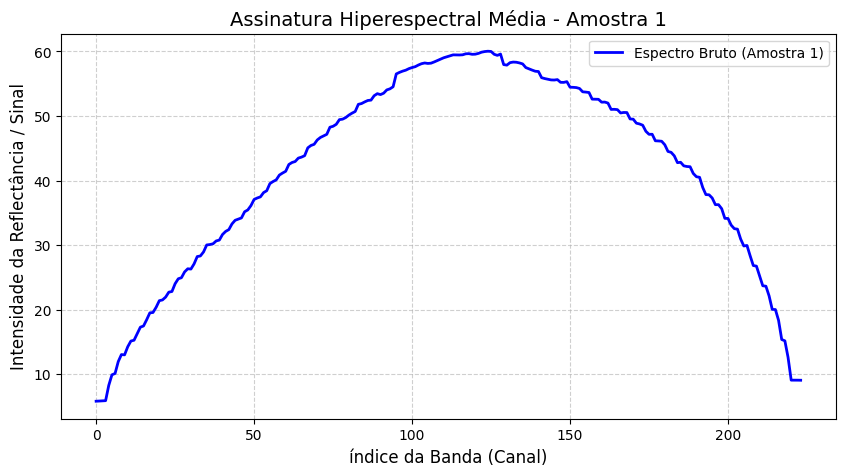

In [5]:
#O próximo passo é visualizar a assinatura espectral (gráfico de reflectância) da imagem
#O cubo tem 237 bandas (ou seja, cada pixel tem uma curva com 237 pontos matemáticos)
#Para poder ver a assinatura sem misturar o ruído do cenário, preciso calcular o espectro médio da imagem

import matplotlib.pyplot as plt
import numpy as np

#1 - Calcula a média de todos os pixels para cada uma das 237 bandas
#Vai reduzir a matriz 3D (237, 224, 224) para um vetor unidimensional de 237 pontos
espectro_medio = np.mean(cubo_hsi, axis=(0, 1))

#2- Configura o tamanho do gráfico
plt.figure(figsize=(10, 5))

#3 - Curva espectral bruta
plt.plot(espectro_medio, color='blue', linewidth=2,
         label='Espectro Bruto (Amostra 1)')

#4 - Títulos e rótulos dos eixos
plt.title('Assinatura Hiperespectral Média - Amostra 1', fontsize=14)
plt.xlabel('índice da Banda (Canal)', fontsize=12)
plt.ylabel('Intensidade da Reflectância / Sinal', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

#5 - mostra o gráfico
plt.show()

In [6]:
#A lógica funcionou para a primeira imagem. Agora será automatizado para todas outras bactérias

#Vou abrir imagem por imagem dentro de um loop, calcular a média de cada uma e guardar tudo numa matriz X

import numpy as np
import tifffile as tiff
import os

#1 - Lista para armazenar os espectros (X) e os IDs correspondentes
espectros_lista = []
ids_processados = []

print("Iniciando a extração dos espectros médios de todas as bactérias...")

#2 - Loop para percorrer cada linha do DataFrame filtrado
for idx, row in df_bacterias.iterrows():
  record_id = int(row['Record_ID'])

  #Reconstroi o nome do arquivo
  nome_arquivo = f"hyperspec_{record_id:04d}.tiff"
  caminho_imagem = os.path.join(caminho_projeto, nome_arquivo)

  #verifica se o arquivo realmente exista na pasta
  if os.path.exists(caminho_imagem):
    #Lê a imagem e extrai a média das bandas espectrais
    cubo = tiff.imread(caminho_imagem)
    media_espectral = np.mean(cubo, axis=(1, 2))

    #Guarda os dados extraídos nas listas
    espectros_lista.append(media_espectral)
    ids_processados.append(record_id)
  else:
    print(f"Aviso: Arquivo '{nome_arquivo}' não encontrado no Drive.")

#3 - Converte a lista final em uma matriz do NumPy (Matriz X)
X_bruto = np.array(espectros_lista)

print("\n--- Processamento concluído! ---")
print(f"Dimensões da matriz final X (Amostras, Bandas): {X_bruto.shape}")

Iniciando a extração dos espectros médios de todas as bactérias...

--- Processamento concluído! ---
Dimensões da matriz final X (Amostras, Bandas): (312, 237)


In [7]:
#A matriz X foi concluída, agora vem a matriz Y
#Para aplicar qualquer modelo quimiométrico ou de IA (como PLS-DA ou Random Forest), o algoritmo precisa de:
  #Matrix X: curvas espectrais que acabei de extrair
  #Matriz ou vetor Y: diz ao algoritmo qual espécie de bactéria cada uma das curvas pertence

#Agora preciso converter as colunas binarias em uma única coluna de texto ou números que represente a classe real daquela linha

#1 - Define-se a lista de colunas que representam as espoécies bacterianas
colunas_especies = ["'E.coli'", "'E.faecalis'", "'S.aureus'",
                    "'K.pneumoniae'", "'P.aeruginosa'"]

#2 - Para cada linha, tenho que descobrir qual coluna tem o valor 1.0 e extrair o nome da espécie
#O método idxmax(axis=1) encontra o nome da coluna que possui o valor máximo (no caso 1.0)
y_classes = df_bacterias[colunas_especies].idxmax(axis=1)

#3 - Limpar as aspas simples dos nomes para deixar masi organizado
y_classes = y_classes.str.replace("'", "")

#4 - Converter para um array numpy para ficar pronto para os modelos de machine learning
Y = y_classes.to_numpy()

print("--- CONSTRUÇÃO DA MATRIZ Y CONCLUÍDA ---")
print(f"Dimensões do vetor Y (Rótulos): {Y.shape}")
print("\nDistribuição real de bactérias por espécie no modelo: ")
print(y_classes.value_counts())

--- CONSTRUÇÃO DA MATRIZ Y CONCLUÍDA ---
Dimensões do vetor Y (Rótulos): (312,)

Distribuição real de bactérias por espécie no modelo: 
E.coli          118
S.aureus         66
E.faecalis       58
K.pneumoniae     48
P.aeruginosa     22
Name: count, dtype: int64


Plotando os espectross brutos e aplicando a normalização SNV...


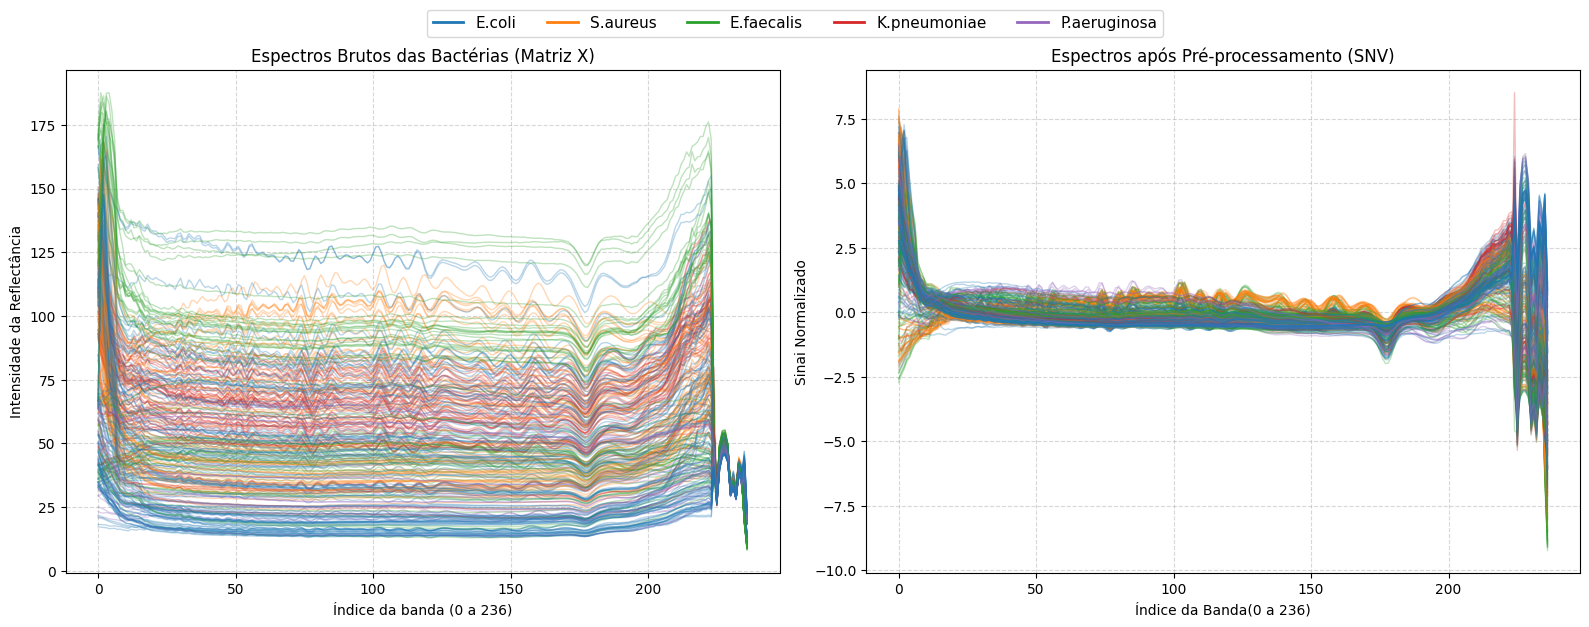

In [8]:
#Visualização de dados e pré processamento quimiométrico

#Antes de enviar as matrizes brutas para um modelo de machine learning (como psl-da), é necessário analisar visualmente como essas 312 curvas espectrais se comportam juntas a plicar um pré processamento
#Isso serve para remover variações físicas indesejadas e destacar apenas a variância química real das bactérias

#Portanto, agora vou:
  #1- plotar todas 312 curvas de uma vez, mas separadas por cores de acordo com a espécie da bactérias. Isso serve para enxergar visualmente se os perfis espectrais já mostram alguma separação ou sobreposição
  #2 - aplicar a normalização padrão (snv - standard normal variate), que é o pré processamento para corrigir desbios globais de amplitude nas curvas

import matplotlib.pyplot as plt
import numpy as np

#1 - defino uma paleta de cores para identificar visualmente cada espécie no gráfico
cores_mapeamento = {
    'E.coli': '#1f77b4', #azul
    'S.aureus': '#ff7f0e', #laranja
    'E.faecalis': '#2ca02c', #verde
    'K.pneumoniae': '#d62728',# vermelho
    'P.aeruginosa': '#9467bd'#roxo
}

#2- configurando a figura com dois subplots (lado a lado): bruto vs pré processado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

print("Plotando os espectross brutos e aplicando a normalização SNV...")

#3 - Loop para plotar cada uma das 312 amostras no gráfico da esquerda
for i in range(len(X_bruto)):
  especie_atual = Y[i]
  cor = cores_mapeamento.get(especie_atual, '#7f7f7f')
  ax1.plot(X_bruto[i], color=cor, alpha=0.3, linewidth=1)

ax1.set_title('Espectros Brutos das Bactérias (Matriz X)', fontsize=12)
ax1.set_xlabel('Índice da banda (0 a 236)')
ax1.set_ylabel('Intensidade da Reflectância')
ax1.grid(True, linestyle='--', alpha=0.5)

#4 - Aplicação do pré processamento: SNV (Standard normal variate)
#O snv subtrai a média de cada amostra e divide pelo seu desvio padrão individual
X_snv = np.zeros_like(X_bruto)
for i in range(len(X_bruto)):
  X_snv[i] = (X_bruto[i] - np.mean(X_bruto[i])) / np.std(X_bruto[i])

#5 - plotando as mesmas 312 amostras após o SNV no gráfico da direita
for i in range(len(X_snv)):
  especie_atual = Y[i]
  cor = cores_mapeamento.get(especie_atual, '#7f7f7f')
  ax2.plot(X_snv[i], color=cor, alpha=0.3, linewidth=1)

ax2.set_title('Espectros após Pré-processamento (SNV)', fontsize=12)
ax2.set_xlabel('Índice da Banda(0 a 236)')
ax2.set_ylabel('Sinai Normalizado')
ax2.grid(True, linestyle='--', alpha=0.5)

#6- criando uma legenda personalizada para o gráfico
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, lw=2, label=esp) for esp, c in cores_mapeamento.items()]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5, fontsize=11)

plt.tight_layout()
plt.show()

Dados de Treino: 249 amostras
Dados de Teste: 63 amostras

--- Relatório de Classificação ---
              precision    recall  f1-score   support

      E.coli       0.81      0.71      0.76        24
  E.faecalis       0.75      1.00      0.86        12
K.pneumoniae       0.67      0.60      0.63        10
P.aeruginosa       0.67      0.50      0.57         4
    S.aureus       0.86      0.92      0.89        13

    accuracy                           0.78        63
   macro avg       0.75      0.75      0.74        63
weighted avg       0.78      0.78      0.77        63



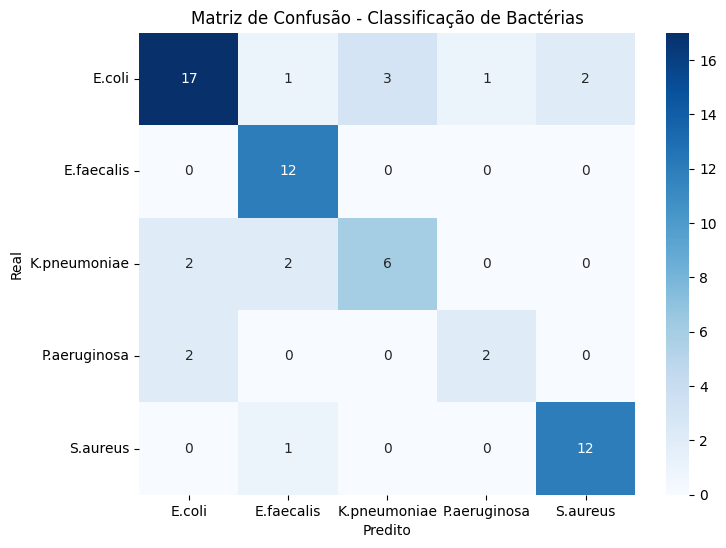

In [9]:
#Treinar a IA e pegar a acurácia geral do modelo e a tabela visual de acertos por espécie

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#1 - divisão dos dados em treino (80%) e teste (20%)mantendo a proporção das classes (stratify)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_snv, Y, test_size=0.2, random_state=42, stratify=Y
)

print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras\n")

#2 - inicializa e treina o classificador
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, Y_train)

#3 - predição nos dados de teste para avaliar o modelo
Y_pred = modelo_rf.predict(X_test)

#4-Exibe o relatório de métricas (Acurácia, precião, recall)
print("--- Relatório de Classificação ---")
print(classification_report(Y_test, Y_pred))

#5- plota a matriz de confusão para ver onde o modelo acertou ou errou
matriz_confusao = confusion_matrix(Y_test, Y_pred, labels=modelo_rf.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_rf.classes_, yticklabels=modelo_rf.classes_)
plt.title('Matriz de Confusão - Classificação de Bactérias')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

#O QUE FOI FEITO ATÉ AQUI

#MAPEAMENTO E FILTRAÇÃO DO DATASET: Importei as tabelas de registro e limpei a base de dados original. Filtrei o dataframe para remover todas as 58 amostras de fungos (candida albicans), isolando com sucesso um conjunto de dados puramente bacteriano contendo 312 amostras

#EXTRAÇÃO DE ASSINATURAS HIPERESPECTRAIS (Matriz X): Algoritmo automatizado para percorrer todos os 312 cubos de dados 3D. O código calculou a média espacial de cada iamgem (Esmagando os eixos de altura e largura de 224x224 pixels) para extrair o espectro contínuo puro de cada bactéria, consolidando a Matriz X com dimensões exatas de 312 amostras, 237 bandas espectrais

#CONSTRUÇÃO DOS RÓTULOS: Foram convertidas as colunas binárias de espécies em um vetor unidimensional contendo os nomes das respectivas classes (E. coli, S. aureus, E. faecalis, K. pneumoniae, P. aeruginosa)

#PRÉ PROCESSAMENTO QUIMIOMÉTRICO: Foi aplicado a técnica de SNV (Standard Normal Variate) sobre as curvas biológicas brutas para corrigir os desvios globais de linha de base e os efeitos físicos de espalhamento de luz provocados pela morfologia das colônias

#VALIDAÇÃO DO MODELO INICIAL: Dividi as matrizes em 80% para treino e 20% para teste. Treinei um classificador baseado no algoritmo Random Forest, alcançando uma acurácia global inicial de 78%. O modelo um desempenho considerável na identificação de bactérias Gram-positivias (E.faecalis com 100% de recall e S.aureus com 92%), apresentando confusões pontuais entre as Gram-negativas da mesma familia biológica (E. coli e K. pneumoniae)

---------------------------------------

#O QUE SERÁ FEITO

#EXPLORAÇÃO DE NOVOS PRÉ-PROCESSAMENTOS: Testar a aplicação da Primeira e Segunda Derivada (Savitzky-Golay) nos espectros para resolver problemas de sobreposição de bandas e destacar picos químicos sutis das bactérias Gram-negativas

#ANÁLISE DE COMPONENTES PRINCIPAIS (PCA): Implementar o PCA sobre a matriz X pré processada para reduzir a dimensionalidade das 237 variáveis e plotar gráficos de scores (Scores Plot 2D/3D), permitindo avaliar visualmente o agrupamento e a separação natural das espécies bacterianas

#BENCHMARKING DE MODELOS: Substituir ou estender o modelo atual testando algoritmos robustos para matrizes hiperespectrais contínuas, especificamente o PLS-DA (Mínimos Quadrados Parciais com análise discriminante) e o SVM(support vector machine), comparando as matrizes de confusão finais

#LEMBRANDO QUE POR SE TRATAR DE BACTÉRIA (SERES VIVOS), A EFICÁCIA NUNCA SERÁ 100%, JÁ QUE SERES VIVOS SÃO IMPREVISIVEIS E NÃO SÃO IGUAIS
